In [1]:
%load_ext autoreload
%autoreload 2

# **Análisis Exploratorio de Datos** (EDA)

---

In [ ]:
import sys
sys.path.append("..")

from sklearn.metrics import cohen_kappa_score, confusion_matrix

from src.data import EDA, STAGES_LABELS
import src.plots as plots
import src.metrics as metrics

## Dataset: **BIDSleep**

Se compone de datos de 47 pacientes (BidslabXX) sanos con grabaciones de entre 3 a 7 noches de (1) la frecuencia cardiaca instantánea (IHR) y (2) 3 ejes de acelerometría medidos por un Apple Watch con un total de 253 noches de datos. Cada época (lapsos de 30 segundos) vienen etiquetados por un experto (*expert_label*) y el dispotitivo "Dreem 2 Headband" (*dreem_label*), un monitor de sueño portátil.

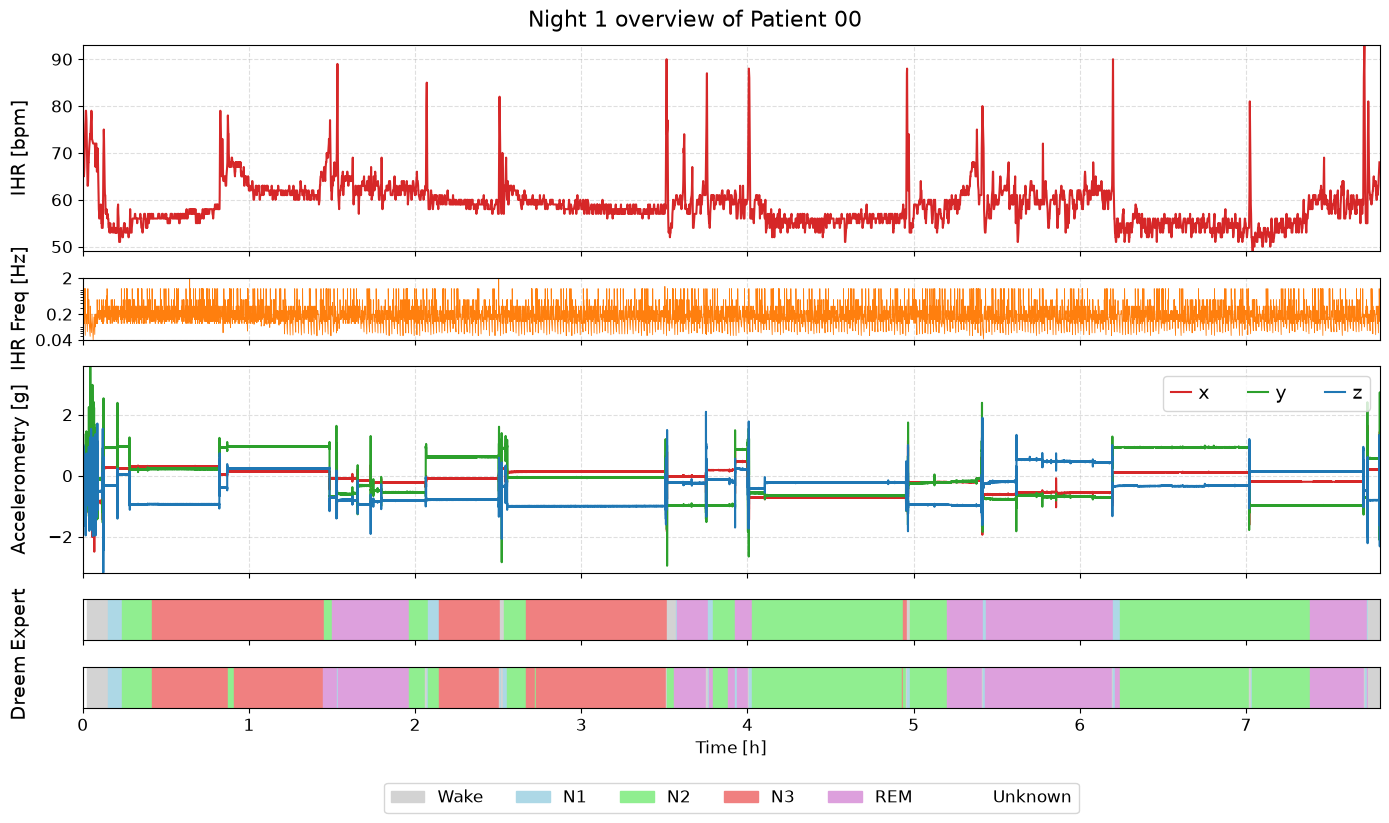

In [11]:
patient, night = 0, 1
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

Encontramos noches con datos inconsistentes y/o mal condicionados como por ejemplo el siguiente en el que los timestamps indican una duración de $\sim30$ horas, por lo que debimos analizar la calidad de cada noche.

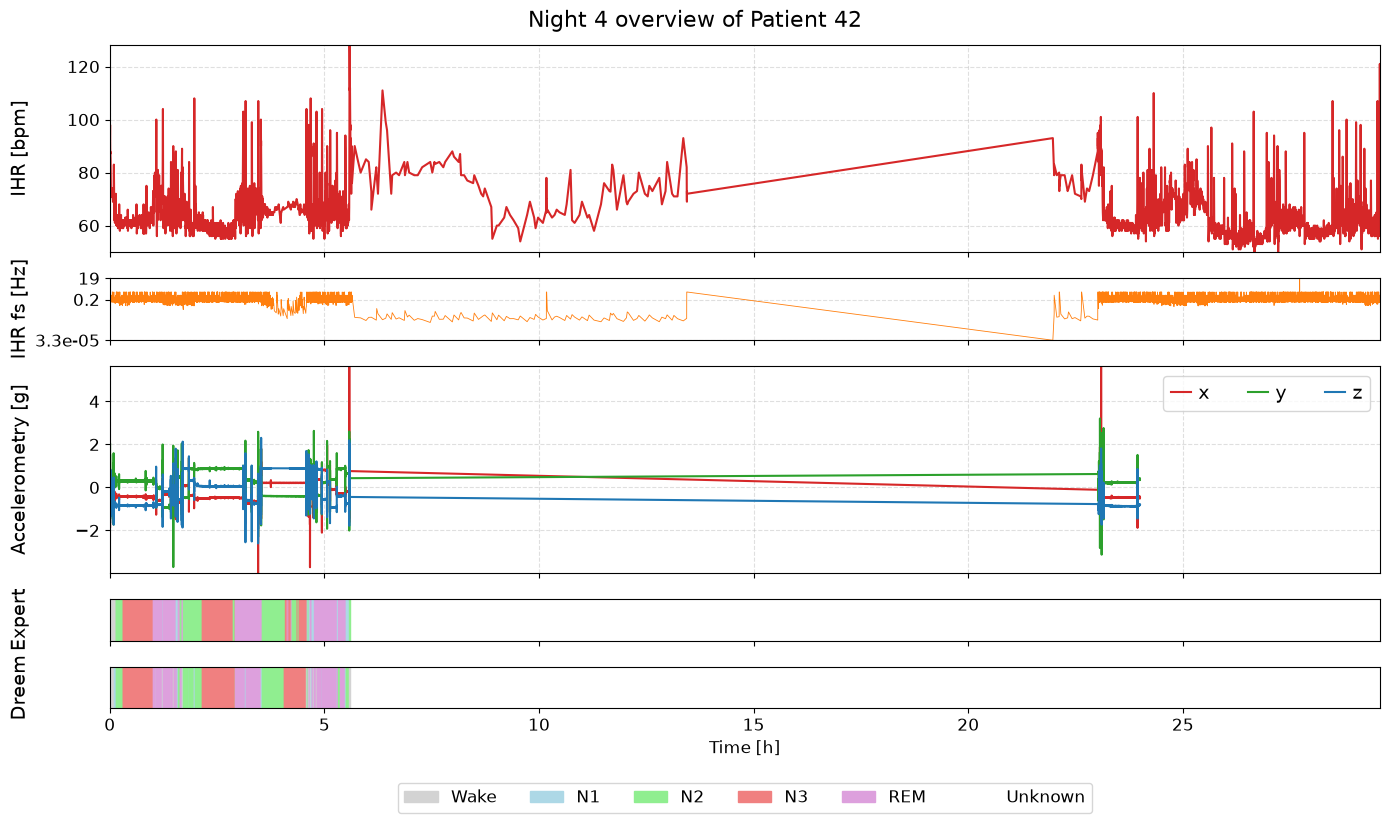

In [10]:
patient, night = 42, 4
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

## Evaluación de calidad de los datos.

El test de calidad define la **ventana válida** de cada noche a partir de la extensión del etiquetado del experto (`expert_label`). Pero cada noche tiene además el etiquetado del dispositivo Dreem (`dreem_label`), y ambos no tienen por qué cubrir exactamente el mismo lapso temporal. Antes de definir la ventana válida verificamos entonces en cuántas noches difieren en extensión `expert_label` y `dreem_label`, y por cuánto.

In [11]:
mismatches = EDA.label_length_mismatch()

print(f'Noches con distinta extensión entre expert y dreem: {len(mismatches)} / 253\n')
for m in mismatches:
    print(f"Paciente {m['patient']:02d} Noche {m['night']}: "
          f"expert = {m['n_expert']} epochs, dreem = {m['n_dreem']} epochs "
          f"(dif {m['diff_epochs']:+d} epochs = {m['diff_s']:+d}s)")

Noches con distinta extensión entre expert y dreem: 2 / 253

Paciente 01 Noche 4: expert = 771 epochs, dreem = 935 epochs (dif +164 epochs = +4920s)
Paciente 30 Noche 6: expert = 851 epochs, dreem = 849 epochs (dif -2 epochs = -60s)


En **251 de las 253 noches** ambos etiquetados tienen exactamente la misma extensión, y sólo difieren en dos casos:

- **Paciente 01 Noche 4**: `expert` cubre 771 epochs y `dreem` 935 (dreem se extiende 164 epochs = 1.37h más). Como `expert` es el más corto, su ventana queda **contenida** en la de dreem.
- **Paciente 30 Noche 6**: `expert` cubre 851 epochs y `dreem` 849 (expert se excede en apenas 2 epochs = 60s).

Tomando la ventana válida según `expert_label` cubrimos siempre el lapso etiquetado por ambos: en P01 N4 la ventana de expert está incluida en la de dreem, y en P30 N6 el exceso es de sólo 60s (1 noche, despreciable). Como además el test de calidad evalúa la cobertura de HR sobre las etiquetas del experto, **`expert_label` define la ventana válida** usada en el análisis que sigue.

`EDA.quality_report()` recorre las 253 noches y calcula, para cada una, métricas de calidad de señal:

- **Gaps temporales** en `hr.csv` y `motion.csv`: intervalos entre muestras consecutivas mayores a $\texttt{GAP\_THRESHOLD\_S} = 60s$, que indican períodos sin medición (el dispositivo interpola linealmente los valores faltantes en ese rango).
- **Duración total** (`hr_span_h`): horas que abarca la señal de `hr.csv`. Una noche dura $\approx$ 8h; valores muy por encima indican que el registro se extiende más allá de la ventana etiquetada (ese exceso se trunca al construir el dataset). Es una métrica informativa, no un criterio de descarte.
- **Valores NaN** (`hr_nan_count`, `motion_nan_count`): filas con datos faltantes en cada señal.
- **Acelerometría inválida**: fracción de muestras donde $|\sqrt{x^2+y^2+z^2} - 1| > \texttt{ACC\_TOL} = 0.5g$. En reposo, la norma del vector de aceleración debería ser exactamente $1g$ (gravedad); sin embargo, desviaciones grandes también ocurren por movimiento real del cuerpo, por lo que no se usa como criterio de descarte.
- **IHR inválido**: muestras con $\texttt{hr <= 0}$ ó $\texttt{hr > 200 bpm}$ (excluyendo los bordes de la grabación).

A partir de estas métricas definimos la **ventana válida** de cada noche: la intersección entre la ventana etiquetada $[\texttt{recStart},\ \texttt{recStart} + \texttt{label\_span\_s}]$ y el rango de señal **continua** de `hr.csv`. Un gap cuya señal sólo reanuda *fuera* del etiquetado (típico de noches que siguen grabando de día) se trata como borde, no como discontinuidad interna. Comparando la señal con la ventana etiquetada surgen cinco desajustes posibles:

- **`leading_trunc_s` / `trailing_trunc_s`**: labels sin señal al inicio / fin (la ventana etiquetada se extiende más allá de la señal continua).
- **`head_excess_s` / `tail_excess_s`**: señal sin label antes / después del etiquetado (la señal se extiende más allá de las labels).
- **`internal_gap_s`**: suma de gaps de `hr.csv` *dentro* de la ventana válida, recortados a esa ventana — discontinuidades en medio de la secuencia, con datos a ambos lados.

**Una noche es problemática si requiere alguna modificación**, es decir, si la señal y las labels no cubren exactamente el mismo período (más allá de `ALIGN_TOL_S = 30s`, una epoch). Sólo las noches ya alineadas quedan fuera. Cada noche problemática se etiqueta con el tipo de modificación que necesita:

1. **`signal_excess`** (`head_excess_s` / `tail_excess_s`): hay señal fuera del etiquetado. **Solución: recortar la señal** (no puede haber muestras sin label). Es la modificación más común y trivial.
2. **`label_trunc`** (`leading_trunc_s` / `trailing_trunc_s`): hay labels sin señal. **Solución: recortar las labels** (no puede haber epochs etiquetadas sin HR).
3. **`internal_gap`** (`internal_gap_s > INTERNAL_GAP_THRESHOLD_S = 10min`): discontinuidad real dentro de la ventana válida, que no se resuelve truncando. **Solución: descartar o reparar** la noche; se decide al construir el dataset.

La lista completa se guarda en `analysis/problematic_nights.json`. Todas las modificaciones se aplican en memoria al construir el dataset, sin modificar los archivos originales (el notebook es reproducible).

In [ ]:
df_quality = EDA.quality_report()

Paciente 00 - Noche 2:   0%|          | 1/253 [00:00<03:35,  1.17it/s]

In [ ]:
problematic_nights = EDA.problematic_nights(df_quality)

print(f'Noches que requieren modificación: {len(problematic_nights)} / {len(df_quality)} '
      f'({100*len(problematic_nights)/len(df_quality):.1f}%)')

from collections import Counter
combos = Counter(tuple(n['modifications']) for n in problematic_nights)
for combo, count in combos.most_common():
    print(f'  {count:3d}  {" + ".join(combo)}')

El `.json` lista **todas** las noches que requieren alguna modificación (228 de 253; sólo 25 ya están alineadas), cada una con su tipo de modificación. La mayoría son simple `signal_excess` (señal sobrante fuera del etiquetado, que se recorta trivialmente — como la noche P8 N1 que vimos arriba).

El overview de abajo grafica sólo el subconjunto que **pierde labels o tiene gaps** (truncamiento de extremo $>1$h o gap interno), que es lo interesante de inspeccionar. En cada gráfico, la **ventana válida** (lo que se conserva) se sombrea en verde con sus bordes marcados; los labels sin señal que se recortan, en naranja; y los gaps internos, en rojo. El rótulo indica la métrica significativa de cada caso.

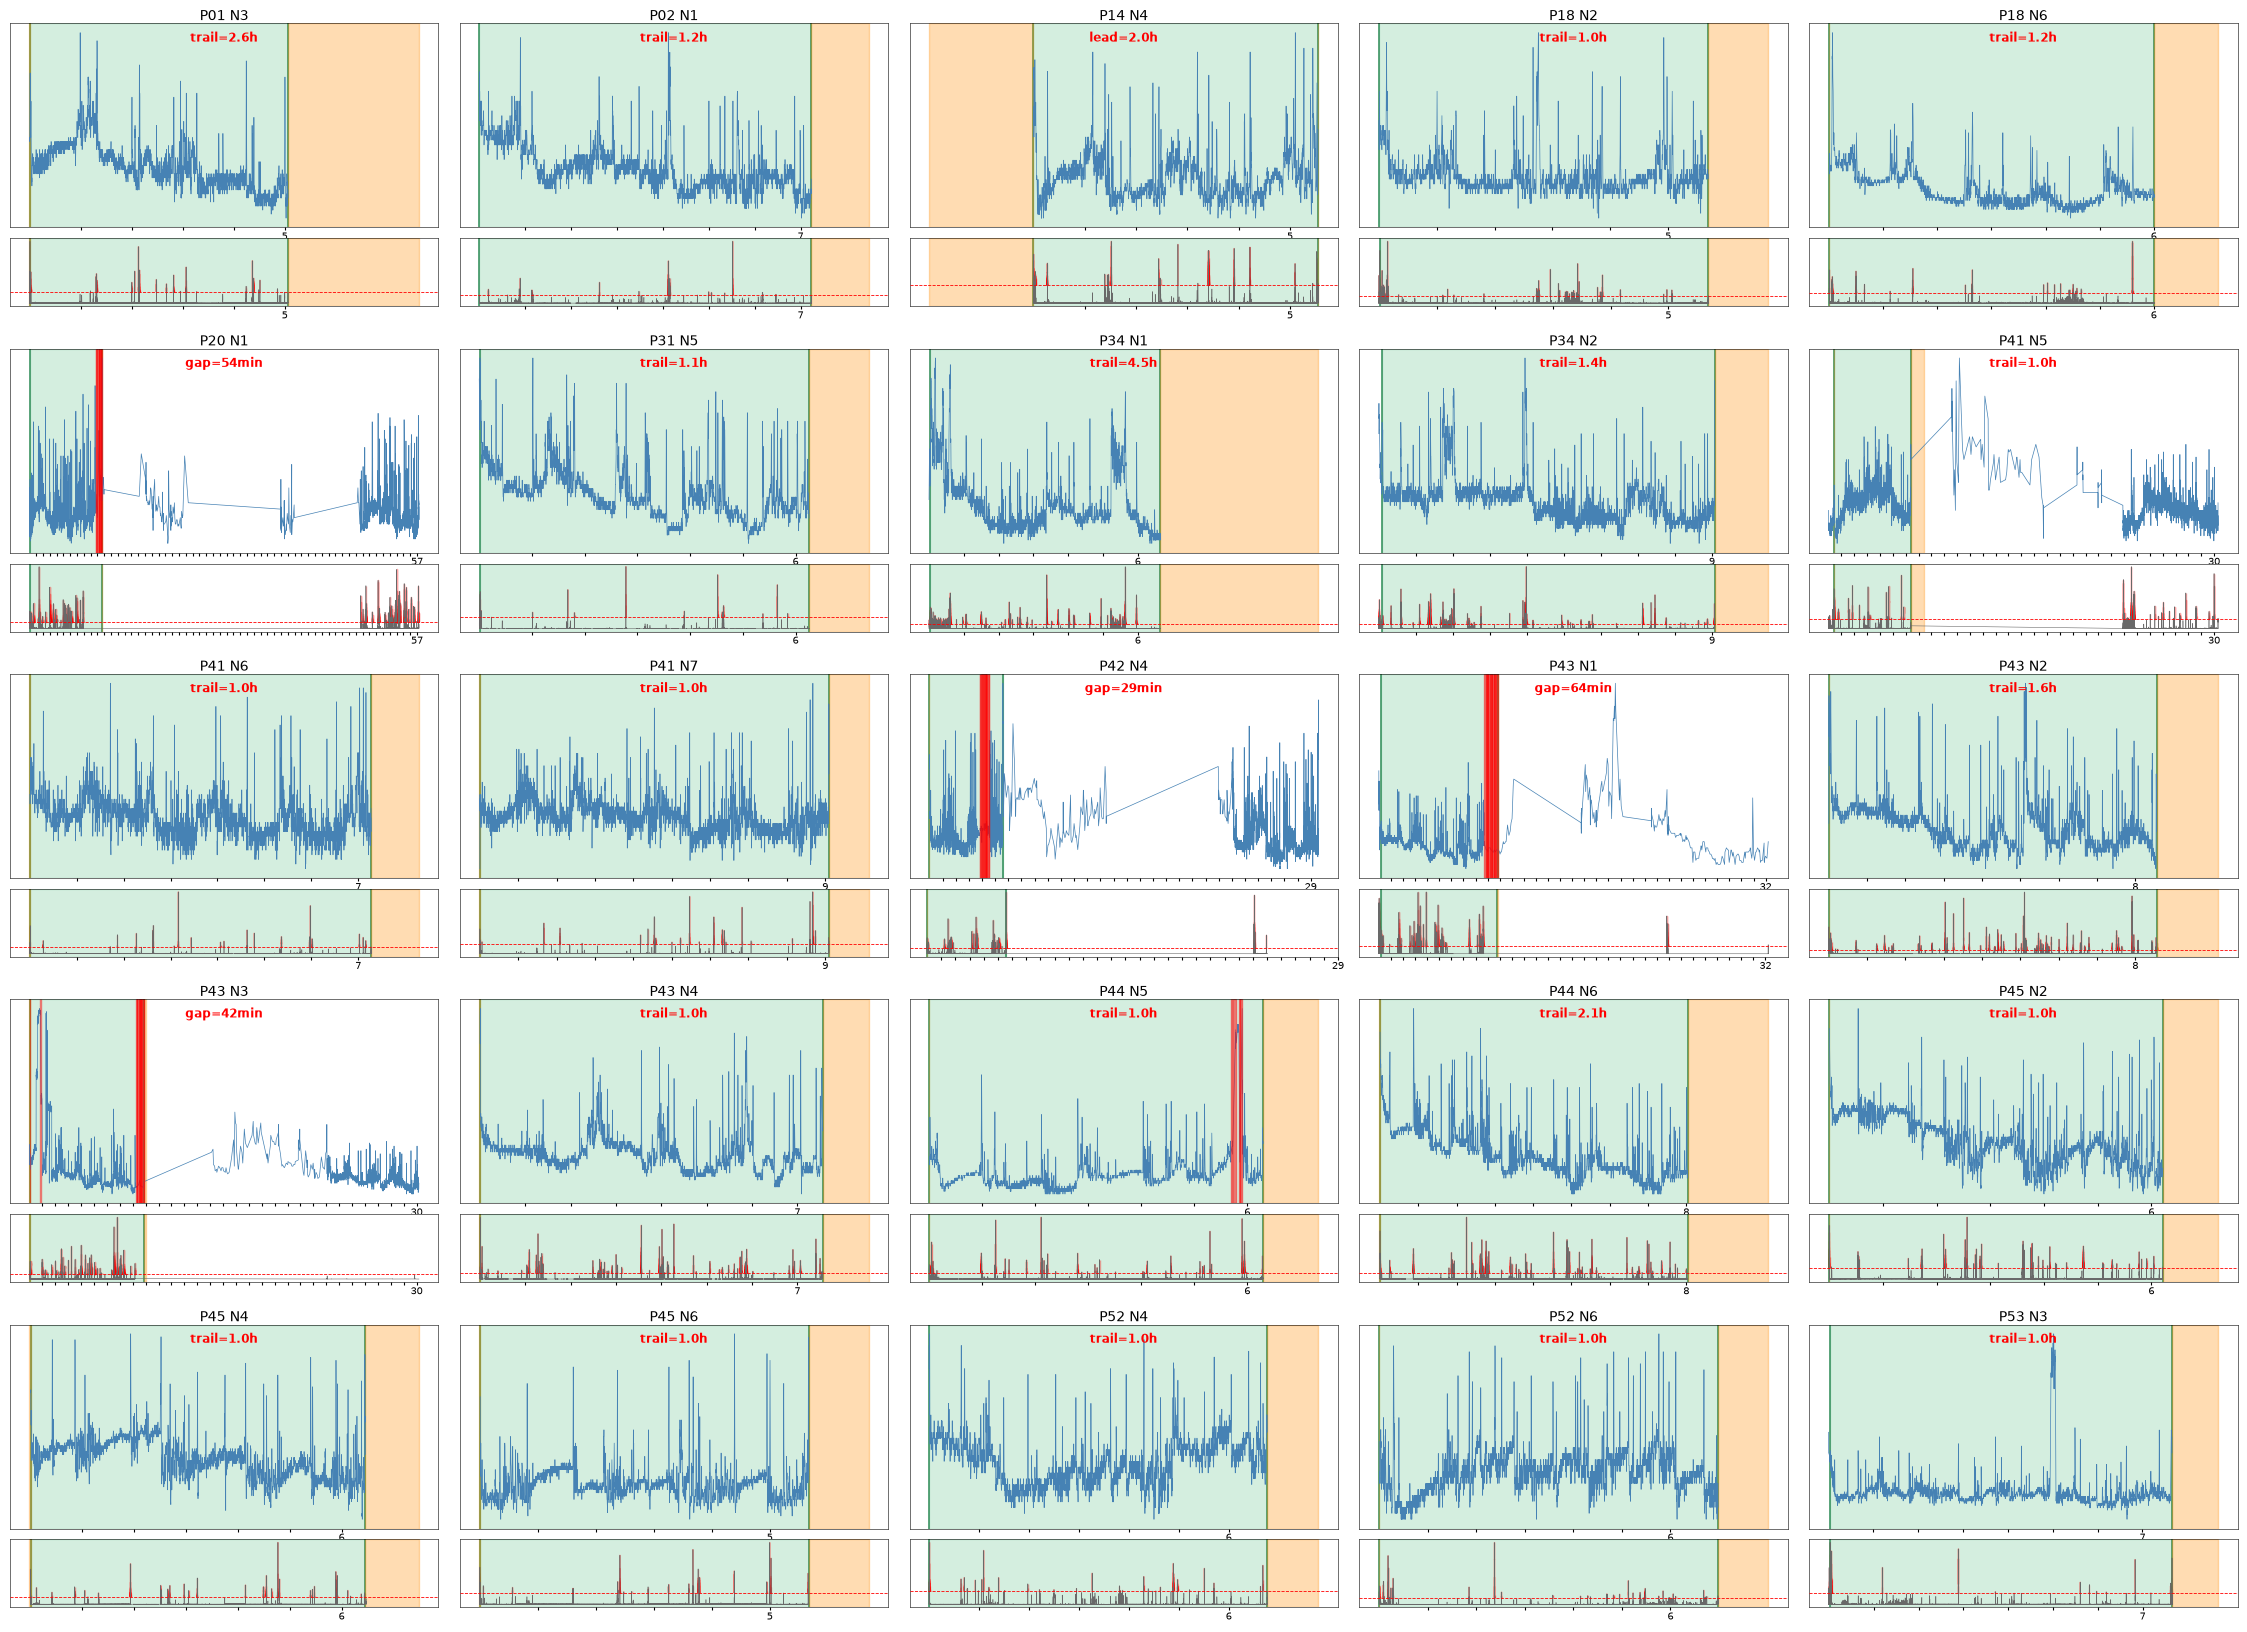

In [ ]:
plots.problematic_nights_overview(ncols=5)

### Distribución de Etapas de Sueño

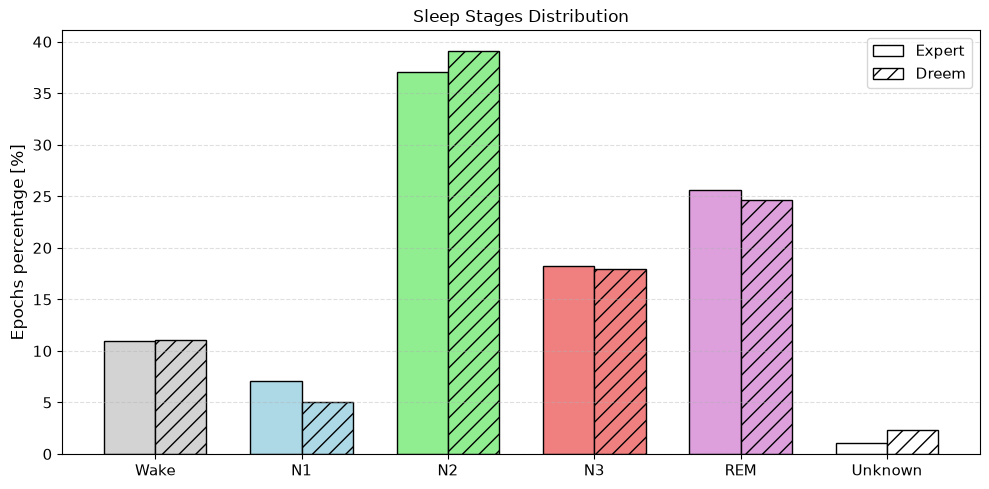

In [ ]:
distributions = EDA.class_distribution()
plots.class_distribution(distributions)

### Labels **Expert** vs **Dreem**

**Cohen's Kappa** mide el *acuerdo* entre dos clasificadores (en este caso, el etiquetado del experto y el del dispositivo Dreem) corrigiendo por el acuerdo que se esperaría por azar dado el desbalance de clases (Cohen, 1960). Se define como:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde:
- $p_o$ es la **proporción observada de acuerdo** (accuracy): fracción de epochs donde ambos etiquetados coinciden.
- $p_e$ es la **proporción de acuerdo esperada por azar**, calculada a partir de las distribuciones marginales de cada clasificador: $p_e = \sum_k \frac{n_{k\cdot} \cdot n_{\cdot k}}{n^2}$, con $n_{k\cdot}$ y $n_{\cdot k}$ las marginales de fila/columna de la matriz de confusión y $n$ el total de epochs.

**Valores que puede tomar:**
- $\kappa = 1$: acuerdo perfecto.
- $\kappa = 0$: el acuerdo observado es igual al esperado por azar (no hay acuerdo más allá del azar).
- $\kappa < 0$: el acuerdo es peor que el azar (desacuerdo sistemático).
- En general $-1 \le \kappa \le 1$.

**Interpretación habitual [(Landis & Koch, 1977)](http://doi.org/10.2307/2529310):** $<0$ sin acuerdo, $0$–$0.2$ leve, $0.2$–$0.4$ aceptable, $0.4$–$0.6$ moderado, $0.6$–$0.8$ sustancial, $0.8$–$1$ casi perfecto.

Además del valor global, se calcula $\kappa$ **por clase** mediante un esquema one-vs-rest: para cada etapa $k$ se binariza el problema (¿es clase $k$ o no?) y se computa $\kappa$ sobre esa matriz de confusión 2x2, lo que permite identificar en qué etapas específicas el experto y Dreem difieren más.

In [ ]:
expert, dreem = EDA.all_labels()
kappa_global = cohen_kappa_score(expert, dreem)
kappa_per_class = metrics.cohen_kappa_per_class(expert, dreem)

labels = ['K (global)'] + [f'K ({stage})' for stage in STAGES_LABELS.values()]
label_width = max(len(l) for l in labels)

print(f'{labels[0]:<{label_width}} = {kappa_global:.4f}')
for label, k in zip(labels[1:], kappa_per_class):
    print(f'{label:<{label_width}} = {k:.4f}')

In [ ]:
cm = confusion_matrix(expert, dreem, labels=range(6))
plots.confusion_matrix(cm)

### Distribución de la acelerometria en 3D

Se muestra un grafico en 3D de la acerometria del paciente 0 en la noche 1 para analizar la distribución de los datos en función de los labels sobre cada clasficador.

In [ ]:
# EDA.plot_motion_comparison_3d(patient=0, night=1, step=100)

se aprecia como las clasificaciones de dreem capta la estructura de cada label acorde a la clasificación del experto pero presenta ciertas falencias en pequeños grupos de muestras. Por otro lado, se puede identificar como el manifold de los datos representa la superficie de una esfera donde si bien los labels presentan solapamientos, de igual forma se logra ver el sector aproximado de cada uno sobre dicha esfera.

## 2 Enfoques Posibles para definir la **Secuencia**

Para procesar la secuencia de pasos temporales, debemos definir cuál es este paso temporal.

- **Intra-epoch**: el paso temporal es cada muestra dentro de una época (lapso de 30 segundos). Cada época se clasifica de forma independiente.
- **Inter-epoch**: el paso temporal es cada época completa. El modelo mira a lo largo de la noche.